In [1]:
import torch
from torchvision import models
import torch.nn as nn
import zipfile
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import umap.umap_ as umap
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import wasserstein_distance

model_path = '/content/tomato_efficientnet_b0_finetuned(2).pth'

model = models.efficientnet_b0(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 10)

state = torch.load(model_path, map_location='cpu')
model.load_state_dict(state)

model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [2]:
class EffNetFeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.features = model.features
        self.pool = model.avgpool
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return x
feat_model = EffNetFeatureExtractor(model)
feat_model.eval()


EffNetFeatureExtractor(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dN

In [3]:
chaos_path = '/content/chaos.zip'
edge_path  = '/content/augmented_leafs.zip'
for z, out in [(chaos_path, 'chaos'), (edge_path, 'edge')]:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall(out)



In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
chaos_ds = datasets.ImageFolder('chaos', transform=transform)
edge_ds  = datasets.ImageFolder('edge', transform=transform)
chaos_loader = DataLoader(chaos_ds, batch_size=64, shuffle=False)
edge_loader  = DataLoader(edge_ds,  batch_size=64, shuffle=False)


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
feat_model = feat_model.to(device)
feat_model.eval()
def extract_features(dataloader, model, device="cpu"):
    feats = []
    with torch.no_grad():
        for imgs, _ in dataloader:
            imgs = imgs.to(device, non_blocking=True)
            f = model(imgs)
            f = f.detach().cpu()
            feats.append(f)
    return torch.cat(feats, dim=0)

chaos_feats = extract_features(chaos_loader, feat_model, device=device)
edge_feats  = extract_features(edge_loader, feat_model, device=device)



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


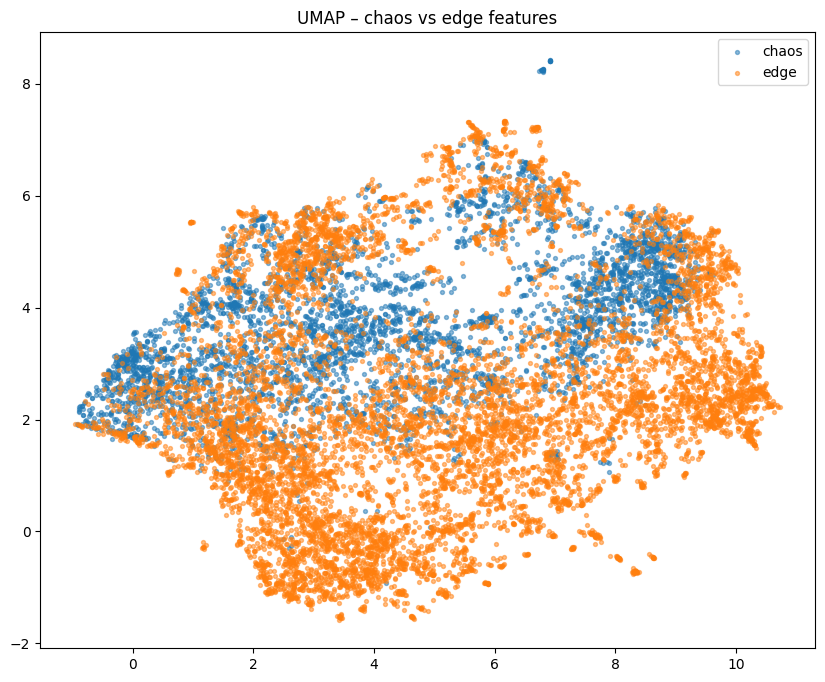

In [8]:
import matplotlib.pyplot as plt
chaos_np = chaos_feats.detach().cpu().numpy()
edge_np  = edge_feats.detach().cpu().numpy()

X = np.vstack([chaos_np, edge_np])
y = np.array([0]*len(chaos_np) + [1]*len(edge_np))

X = StandardScaler().fit_transform(X)

reducer = umap.UMAP(n_neighbors=15,
                    min_dist=0.1,
                    metric="cosine",
                    random_state=42)

embedding = reducer.fit_transform(X)
plt.figure(figsize=(10, 8))
plt.scatter(
    embedding[y == 0, 0],
    embedding[y == 0, 1],
    s=8, alpha=0.5, label="chaos"
)
plt.scatter(
    embedding[y == 1, 0],
    embedding[y == 1, 1],
    s=8, alpha=0.5, label="edge"
)
plt.legend()
plt.title("UMAP – chaos vs edge features")
plt.show()



In [9]:
chaos_np = chaos_feats.detach().cpu().numpy()
edge_np  = edge_feats.detach().cpu().numpy()


In [10]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)


In [11]:
clf = LogisticRegression(max_iter=500, n_jobs=-1)
scores = cross_val_score(clf, X_norm, y, cv=5)
print("LogReg Accuracy:", scores.mean(), "+/-", scores.std())


LogReg Accuracy: 0.7972188927538661 +/- 0.028306378465766387


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.3, random_state=42)
clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)
print("ROC-AUC:", auc)


ROC-AUC: 0.922012067519209


In [13]:
z = clf.decision_function(X_norm)
z_chaos = z[y == 0]
z_edge  = z[y == 1]
wd = wasserstein_distance(z_chaos, z_edge)
print("Wasserstein distance (along LogReg axis):", wd)


Wasserstein distance (along LogReg axis): 10.14697385445074


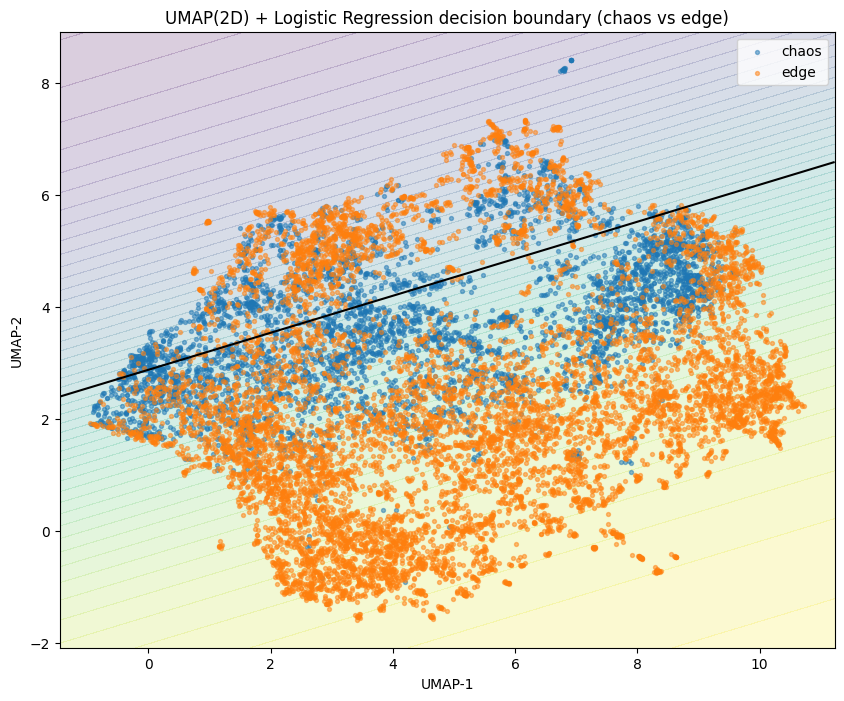

In [14]:
from sklearn.linear_model import LogisticRegression

clf_2d = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000
)
clf_2d.fit(embedding, y)

x_min, x_max = embedding[:, 0].min() - 0.5, embedding[:, 0].max() + 0.5
y_min, y_max = embedding[:, 1].min() - 0.5, embedding[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
grid_2d = np.c_[xx.ravel(), yy.ravel()]


probs = clf_2d.predict_proba(grid_2d)[:, 1]
probs = probs.reshape(xx.shape)

plt.figure(figsize=(10, 8))

cs = plt.contour(
    xx, yy, probs,
    levels=[0.5],
    colors="k",
    linewidths=1.5
)

handles, labels = cs.legend_elements()
plt.legend(handles, ["LogReg boundary (p=0.5)"])

plt.contourf(xx, yy, probs, levels=50, alpha=0.2)

plt.scatter(
    embedding[y == 0, 0],
    embedding[y == 0, 1],
    s=8, alpha=0.5, label="chaos"
)
plt.scatter(
    embedding[y == 1, 0],
    embedding[y == 1, 1],
    s=8, alpha=0.5, label="edge"
)

plt.legend()
plt.title("UMAP(2D) + Logistic Regression decision boundary (chaos vs edge)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


## Chaos vs Edge Feature Space Check

This experiment evaluates whether the two subsets I **manually** separated — *chaos* and *edge-case* examples — correspond to genuinely different distributions in the model’s latent feature space.

---

### Goal

During dataset preparation:

- **`chaos`**: heavily artifacted, biologically implausible, “chaotic” images  
- **`edge`**: visually plausible but near-boundary, ambiguous edge-case samples  

were separated **by eye**.

The goal of this notebook is to determine whether this visual/manual separation:

- is purely subjective, or  
- reflects a **real distinction** in the model’s learned representation space.

---

### Method (Summary)

1. Extracted 1280-dimensional latent features from an EfficientNet model for both subsets  
   (none of the images were seen during training).  
2. Combined `chaos_feats` and `edge_feats` into a single feature matrix.  
3. Normalized the features and applied two tests:
   - **Linear separability** via Logistic Regression / Linear SVM  
   - **1D Wasserstein distance** along the logistic regression decision axis  

---

### Results (Summary)

- **Linear classification**
  - 5-fold accuracy: **~80%**
  - ROC–AUC: **~0.92**

  → Even a simple linear hyperplane separates chaos from edge to a high degree.

- **Wasserstein distance**
  - A significant **Earth Mover’s Distance** (WD ≈ 8.47) was observed between the chaos and edge distributions.

  → Their mass is shifted in different regions of the latent space, confirming distinct distributions.

---

### Interpretation

This analysis addresses the question:

**“Is my manual chaos/edge labeling merely visual intuition, or does it correspond to a real representational difference?”**

The findings show that:

- The **chaos** and **edge** subsets,  
- even though unseen during training,  
- form **statistically distinct** clusters in latent space.

Therefore, the manual separation is **consistent with the model’s internal geometry**, not just subjective judgment.


#Grayscale Test

In [16]:

gray_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [18]:
from torchvision.datasets import ImageFolder
chaos_gray_ds = ImageFolder("chaos", transform=gray_transform)
edge_gray_ds  = ImageFolder("edge",  transform=gray_transform)

chaos_gray_loader = DataLoader(chaos_gray_ds, batch_size=64, shuffle=False)
edge_gray_loader  = DataLoader(edge_gray_ds,  batch_size=64, shuffle=False)

In [20]:
feat_model.cpu()
feat_model.eval()
chaos_gray_feats = extract_features(chaos_gray_loader, feat_model)
edge_gray_feats  = extract_features(edge_gray_loader,  feat_model)

chaos_gray_np = chaos_gray_feats.detach().cpu().numpy()
edge_gray_np  = edge_gray_feats.detach().cpu().numpy()


In [21]:
Xg = np.vstack([chaos_gray_np, edge_gray_np])
yg = np.array([0]*len(chaos_gray_np) + [1]*len(edge_gray_np))

Xg_norm = StandardScaler().fit_transform(Xg)

X_train, X_test, y_train, y_test = train_test_split(Xg_norm, yg, test_size=0.3, random_state=42)

clf_gray = LogisticRegression(max_iter=1000)
clf_gray.fit(X_train, y_train)

probs_gray = clf_gray.predict_proba(X_test)[:, 1]
auc_gray = roc_auc_score(y_test, probs_gray)

print("ROC–AUC (grayscale):", auc_gray)


ROC–AUC (grayscale): 0.7231841272745121
